In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# Load daily stats output from the 1k run
df = pd.read_csv('../data/outputs/1K_80bikeshareagents_seed42.csv')

# Basic sanity checks and context
print(f"Rows (days): {len(df)}")
print(f"Day range: {df['day'].min()} to {df['day'].max()}")
print(f"Initial bike share: {df['bike_share'].iloc[0]:.3%}")
print(f"Final bike share:   {df['bike_share'].iloc[-1]:.3%}")
print(f"Total gain: {(df['bike_share'].iloc[-1] - df['bike_share'].iloc[0]):+.3%}")

df.head()

Rows (days): 35
Day range: 0 to 34
Initial bike share: 70.600%
Final bike share:   72.800%
Total gain: +2.200%


,day,bike_share,car_share,bike_count,car_count,c2b,b2c,net_switch
0,0,0.706,0.294,706,294,0,0,0
1,1,0.705,0.295,705,295,0,1,-1
2,2,0.706,0.294,706,294,1,0,1
3,3,0.707,0.293,707,293,1,0,1
4,4,0.712,0.288,712,288,5,0,5


=== EQUILIBRIUM ANALYSIS ===
Estimated equilibrium onset day: 9
Last 14 days mean bike share: 72.779%
Last 14 days std bike share: 0.041%
Last 14 days range: 72.700% to 72.800% (span 0.100%)
Net switches in last 14 days: +0


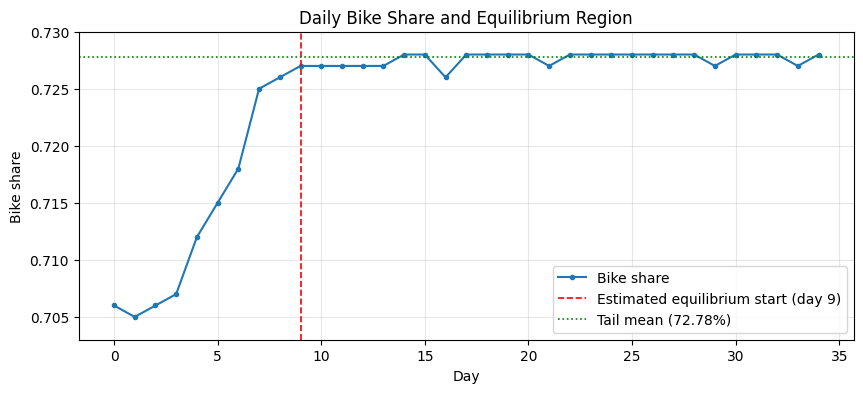

,day,bike_share,c2b,b2c,net_switch
15,15,0.728,0,0,0
16,16,0.726,0,2,-2
17,17,0.728,2,0,2
18,18,0.728,0,0,0
19,19,0.728,0,0,0
20,20,0.728,0,0,0
21,21,0.727,0,1,-1
22,22,0.728,1,0,1
23,23,0.728,0,0,0
24,24,0.728,0,0,0


In [6]:
# Equilibrium diagnostics
# Practical criterion: bike-share rolling range stays very small for a sustained window.
window = 7
range_threshold = 0.0015  # 0.15 percentage points

df = df.sort_values('day').reset_index(drop=True)

# Find first window where range is sufficiently small
rolling_span = (
    df['bike_share']
    .rolling(window=window)
    .apply(lambda x: float(np.max(x) - np.min(x)), raw=True)
)

eq_start_day = None
for idx, span in rolling_span.items():
    if pd.notna(span) and span <= range_threshold:
        eq_start_day = int(df.loc[idx - window + 1, 'day'])
        break

# Tail statistics (last 14 days)
tail_n = min(14, len(df))
tail = df.tail(tail_n)
mean_tail = tail['bike_share'].mean()
std_tail = tail['bike_share'].std(ddof=0)
min_tail = tail['bike_share'].min()
max_tail = tail['bike_share'].max()
span_tail = max_tail - min_tail
net_switch_tail = int(tail['net_switch'].sum())

print('=== EQUILIBRIUM ANALYSIS ===')
if eq_start_day is None:
    print('No stable plateau detected with current range threshold/window settings.')
else:
    print(f'Estimated equilibrium onset day: {eq_start_day}')
print(f'Last {tail_n} days mean bike share: {mean_tail:.3%}')
print(f'Last {tail_n} days std bike share: {std_tail:.3%}')
print(f'Last {tail_n} days range: {min_tail:.3%} to {max_tail:.3%} (span {span_tail:.3%})')
print(f'Net switches in last {tail_n} days: {net_switch_tail:+d}')

# Plot bike share and mark detected equilibrium onset
plt.figure(figsize=(10, 4))
plt.plot(df['day'], df['bike_share'], marker='o', linewidth=1.5, markersize=3, label='Bike share')
if eq_start_day is not None:
    plt.axvline(eq_start_day, color='red', linestyle='--', linewidth=1.2, label=f'Estimated equilibrium start (day {eq_start_day})')
    plt.axhline(mean_tail, color='green', linestyle=':', linewidth=1.2, label=f'Tail mean ({mean_tail:.2%})')

# Auto-zoom Y axis around observed range for better visibility of small changes.
y_pad = max(0.002, span_tail * 0.8)
y_min = max(0.0, float(df['bike_share'].min()) - y_pad)
y_max = min(1.0, float(df['bike_share'].max()) + y_pad)
if y_max - y_min < 0.01:
    mid = 0.5 * (y_min + y_max)
    y_min = max(0.0, mid - 0.005)
    y_max = min(1.0, mid + 0.005)

plt.title('Daily Bike Share and Equilibrium Region')
plt.xlabel('Day')
plt.ylabel('Bike share')
plt.ylim(y_min, y_max)
plt.grid(alpha=0.3)
plt.legend()
plt.show()

# Inspect recent switch activity
df[['day', 'bike_share', 'c2b', 'b2c', 'net_switch']].tail(20)